<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Titanic_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install/import fastai (usually pre-installed on Colab/Kaggle)
from fastai.tabular.all import *
import pandas as pd

In [22]:
# 2. Load the data
df = pd.read_csv('titanic_clean.csv')
df.head()

,Survived,Sex_M_F,Parch,Pclass_1,Pclass_2,Age__1,Fare_log10,SibSp,Embark_S,Embark_C,Ones
0,0.0,1.0,0.0,0.0,0.0,0.28,0.86,1.0,1.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.48,1.85,1.0,0.0,1.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.33,0.90,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.44,1.73,1.0,1.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.44,0.91,0.0,1.0,0.0,1.0


In [23]:
# 3. Define column types
# cat_names -> categorical columns (discrete groups)
# cont_names -> continuous/numeric columns
# procs -> preprocessing fastai applies automatically
cat_names = ['Pclass_1','Pclass_2', 'Sex_M_F', 'SibSp', 'Parch', 'Embark_S','Embark_C','Ones']
cont_names = ['Age_1', 'Fare_log10']
procs = [Categorify, FillMissing, Normalize]

In [10]:
# Generate a random split (default: 20% for validation)
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))

dls = TabularDataLoaders.from_df(
    df,
    y_names="Survived",
    y_block=CategoryBlock,   # <-- forces classification, not regression
    cat_names=cat_names,
    cont_names=cont_names,
    procs=procs,
    splits=splits,
    bs=64
)

In [11]:
# 5. Create the model (fastai picks a sensible default architecture)
learn = tabular_learner(dls, metrics=accuracy)

In [16]:
# 7. Train
learn.fit_one_cycle(10, 1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.395103,0.458619,0.788732,00:00
1,0.364409,0.510068,0.788732,00:00
2,0.365152,0.494618,0.739437,00:00
3,0.371003,0.478920,0.788732,00:00
4,0.355119,0.540332,0.781690,00:00
5,0.357636,0.463181,0.809859,00:00
6,0.361739,0.484054,0.774648,00:00
7,0.360130,0.484471,0.781690,00:00
8,0.354779,0.477877,0.795775,00:00
9,0.349761,0.475479,0.802817,00:00


In [17]:
# 8. Check results
learn.show_results()

,Pclass,Sex,SibSp,Parch,Embarked,Fare_na,Age,Fare,Survived,Survived_pred
0,1.0,2.0,1.0,1.0,1.0,1.0,-0.228737,-0.092675,1.0,1.0
1,2.0,1.0,2.0,1.0,3.0,1.0,-0.024166,-0.169409,1.0,1.0
2,3.0,1.0,2.0,4.0,3.0,1.0,1.271451,-0.008746,0.0,1.0
3,3.0,1.0,1.0,3.0,3.0,1.0,-0.160546,-0.454606,1.0,1.0
4,2.0,2.0,1.0,1.0,3.0,1.0,-0.092356,-0.418796,0.0,0.0
5,3.0,2.0,1.0,1.0,3.0,1.0,0.044025,-0.516713,0.0,0.0
6,3.0,2.0,1.0,1.0,3.0,1.0,0.316786,-0.513755,0.0,0.0
7,3.0,2.0,1.0,1.0,3.0,1.0,-0.774260,-0.518631,0.0,0.0
8,3.0,2.0,1.0,1.0,3.0,1.0,-0.569688,-0.506402,0.0,0.0


In [19]:
print(len(learn.recorder.losses))

0


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

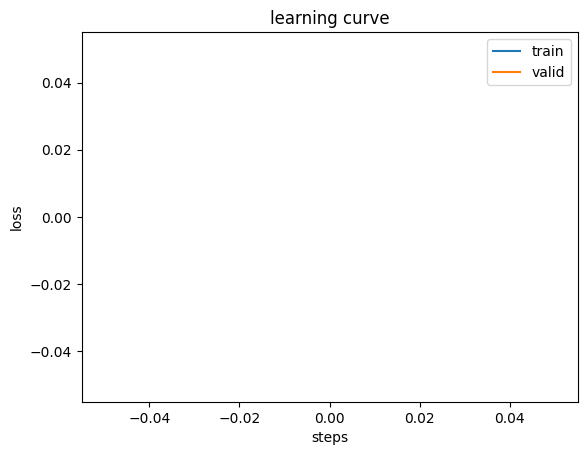

In [18]:
%matplotlib inline

learn.recorder.plot_loss()

<div></div>

epoch,train_loss,valid_loss,accuracy,time
0,0.670928,0.666112,0.669014,00:00
1,0.656442,0.648693,0.704225,00:00
2,0.614076,0.595122,0.760563,00:00
3,0.575577,0.509511,0.781690,00:00
4,0.540354,0.490513,0.774648,00:00
5,0.513948,0.469164,0.802817,00:00
6,0.490053,0.453497,0.781690,00:00
7,0.464430,0.472269,0.774648,00:00
8,0.452868,0.480589,0.774648,00:00
9,0.439152,0.483033,0.774648,00:00


80


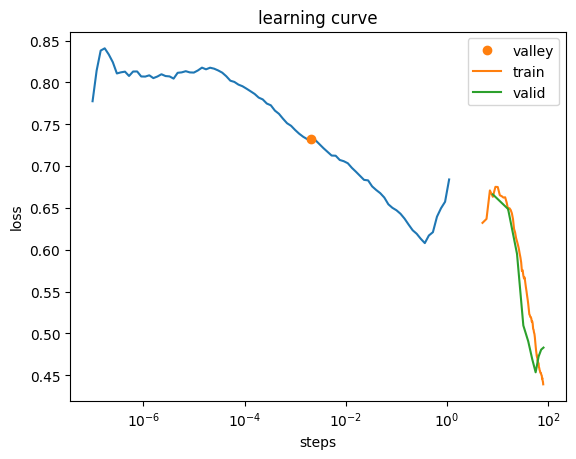

In [31]:
learn = tabular_learner(dls, metrics=accuracy)
learn.lr_find()
learn.fit_one_cycle(10, 1e-2)
print(len(learn.recorder.losses))   # sanity check — should be > 0 now
learn.recorder.plot_loss()
plt.show()


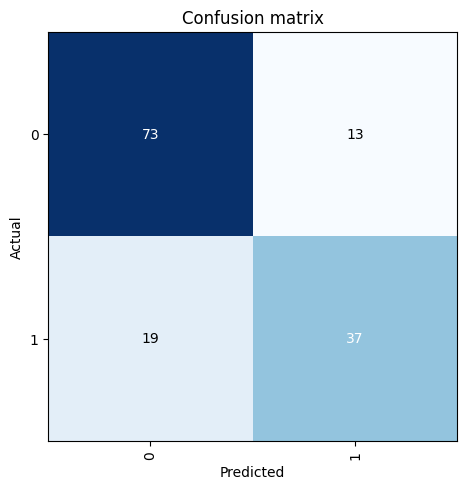

In [32]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()